## Hospital Performance And Efficiancy Analysis
#### This project analyze hospital Performance using multiple healthcare dataset. The goal is to clean, prepare and analyze hospital data to understand the relationship between hospital ratings, medicare spending, and patient outcomes.

In [3]:
# Importing necessary libraries to load, process, analyze and visualize the dataset.
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Loading the Datasets 
#### The three datasets are loaded into Python to begin data cleaning and preparation for analysis.

In [4]:
# Loading hospital general information dataset
hospital_info = pd.read_csv("../data/Hospital_General_Information.csv")
hospital_info.head(5)

,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Hospital Type,Hospital Ownership,...,Count of READM Measures Better,Count of READM Measures No Different,Count of READM Measures Worse,READM Group Footnote,Pt Exp Group Measure Count,Count of Facility Pt Exp Measures,Pt Exp Group Footnote,TE Group Measure Count,Count of Facility TE Measures,TE Group Footnote
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Acute Care Hospitals,Government - Hospital District or Authority,...,0,11,0,NaN,8,8,NaN,12,11,NaN
1,010005,MARSHALL MEDICAL CENTERS,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,(256) 593-8310,Acute Care Hospitals,Government - Hospital District or Authority,...,0,8,1,NaN,8,8,NaN,12,12,NaN
2,010006,NORTH ALABAMA MEDICAL CENTER,1701 VETERANS DRIVE,FLORENCE,AL,35630,LAUDERDALE,(256) 768-8400,Acute Care Hospitals,Proprietary,...,0,8,1,NaN,8,8,NaN,12,10,NaN
3,010007,MIZELL MEMORIAL HOSPITAL,702 N MAIN ST,OPP,AL,36467,COVINGTON,(334) 493-3541,Acute Care Hospitals,Voluntary non-profit - Private,...,0,7,0,NaN,8,8,NaN,12,7,NaN
4,010008,CRENSHAW COMMUNITY HOSPITAL,101 HOSPITAL CIRCLE,LUVERNE,AL,36049,CRENSHAW,(334) 335-3374,Acute Care Hospitals,Proprietary,...,0,2,0,NaN,8,Not Available,5.0,12,6,NaN


## Exploring the Hospital Info Dataset
The structure and contents of the dataset are examined to understand data types, check for missing values, and get the overview of the dataset.

In [5]:
# checking datatypes 
hospital_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5421 entries, 0 to 5420
Data columns (total 38 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Facility ID                                       5421 non-null   object 
 1   Facility Name                                     5421 non-null   object 
 2   Address                                           5421 non-null   object 
 3   City/Town                                         5421 non-null   object 
 4   State                                             5421 non-null   object 
 5   ZIP Code                                          5421 non-null   int64  
 6   County/Parish                                     5421 non-null   object 
 7   Telephone Number                                  5421 non-null   object 
 8   Hospital Type                                     5421 non-null   object 
 9   Hospital Ownership 

In [6]:
# checking number of rows and columns
hospital_info.shape

(5421, 38)

## Data Cleaning: Hospital Info Data
#### In this section, hospital general information dataset is cleaned to prepare it for analysis. the cleaning process includes reviewing columns names, removing unnecessary columns, renaming columns, checking for missing values. The goal is to create a clean dataset that can be easily used for analysis and combined with other datasets.


### step 1 : Inspecting Columns
### In this step, I reviewed all the columns names in the hospital dataset to understand what information is available. This helps identify which columns are useful for the analysis and which ones may not be needed.

In [7]:
# columns for hospital data
hospital_info.columns

Index(['Facility ID', 'Facility Name', 'Address', 'City/Town', 'State',
       'ZIP Code', 'County/Parish', 'Telephone Number', 'Hospital Type',
       'Hospital Ownership', 'Emergency Services',
       'Meets criteria for birthing friendly designation',
       'Hospital overall rating', 'Hospital overall rating footnote',
       'MORT Group Measure Count', 'Count of Facility MORT Measures',
       'Count of MORT Measures Better', 'Count of MORT Measures No Different',
       'Count of MORT Measures Worse', 'MORT Group Footnote',
       'Safety Group Measure Count', 'Count of Facility Safety Measures',
       'Count of Safety Measures Better',
       'Count of Safety Measures No Different',
       'Count of Safety Measures Worse', 'Safety Group Footnote',
       'READM Group Measure Count', 'Count of Facility READM Measures',
       'Count of READM Measures Better',
       'Count of READM Measures No Different', 'Count of READM Measures Worse',
       'READM Group Footnote', 'Pt Exp Gr

### step 2 : Removing Unnecessary Columns
#### some columns in the hospital dataset are not needed for this project. Those columns are removed to make the dataset cleaner and easier to work during analysis.

In [8]:
# Removing the unnecessary columns from hospital data
hospital_info = hospital_info.drop(columns=['Address', 'City/Town',
       'ZIP Code', 'County/Parish', 'Telephone Number',
       'Meets criteria for birthing friendly designation',
        'Hospital overall rating footnote',
       'MORT Group Measure Count', 'Count of Facility MORT Measures',
       'Count of MORT Measures Better', 'Count of MORT Measures No Different',
       'Count of MORT Measures Worse', 'MORT Group Footnote',
       'Safety Group Measure Count', 'Count of Facility Safety Measures',
       'Count of Safety Measures Better',
       'Count of Safety Measures No Different',
       'Count of Safety Measures Worse', 'Safety Group Footnote',
       'READM Group Measure Count', 'Count of Facility READM Measures',
       'Count of READM Measures Better',
       'Count of READM Measures No Different', 'Count of READM Measures Worse',
       'READM Group Footnote', 'Pt Exp Group Measure Count',
       'Count of Facility Pt Exp Measures', 'Pt Exp Group Footnote',
       'TE Group Measure Count', 'Count of Facility TE Measures',
       'TE Group Footnote'], axis=1)
hospital_info.head(5)

,Facility ID,Facility Name,State,Hospital Type,Hospital Ownership,Emergency Services,Hospital overall rating
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,Acute Care Hospitals,Government - Hospital District or Authority,Yes,4
1,010005,MARSHALL MEDICAL CENTERS,AL,Acute Care Hospitals,Government - Hospital District or Authority,Yes,3
2,010006,NORTH ALABAMA MEDICAL CENTER,AL,Acute Care Hospitals,Proprietary,Yes,2
3,010007,MIZELL MEMORIAL HOSPITAL,AL,Acute Care Hospitals,Voluntary non-profit - Private,Yes,1
4,010008,CRENSHAW COMMUNITY HOSPITAL,AL,Acute Care Hospitals,Proprietary,Yes,Not Available


### Data cleaning step 3 : Renaing Columns
#### In this step, A function was created to rename columns.
#### The original dataset contains spaces and special character, which can cause error during analysis. columns are renamed using snake_case formatting.

In [9]:
# column naming function
def rename_columns(df, new_names):
    return df.rename(columns=new_names)

In [10]:
hospital_info= rename_columns(hospital_info,{
    'Facility ID' : 'facility_id',
    'Facility Name' : 'facility_name',
    'State': 'state',
    'Hospital Type' : 'hospital_type',
    'Hospital Ownership' : 'hospital_ownership',
    'Emergency Services' : 'emergency_services',
    'Hospital overall rating' : 'hospital_overall_rating'
    
})

### Step 4: checking for missing values
#### The dataset is examined for missing(Null) values. Identifying missing data is important because it can affect analysis accuracy.

In [11]:
# checking null values
hospital_info.isnull().sum()

facility_id                0
facility_name              0
state                      0
hospital_type              0
hospital_ownership         0
emergency_services         0
hospital_overall_rating    0
dtype: int64

In [12]:
# Information about the dataset
hospital_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5421 entries, 0 to 5420
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   facility_id              5421 non-null   object
 1   facility_name            5421 non-null   object
 2   state                    5421 non-null   object
 3   hospital_type            5421 non-null   object
 4   hospital_ownership       5421 non-null   object
 5   emergency_services       5421 non-null   object
 6   hospital_overall_rating  5421 non-null   object
dtypes: object(7)
memory usage: 296.6+ KB


### Step 5: Checking for Duplicates
In this step, dataset is checked for duplicate rows. Duplicate rows can cause error and may lead to double counting hospital data. Duplicate rows will be identified and removed.

In [13]:
#check duplicates based on facility_id
duplicates_id = hospital_info.duplicated(subset=['facility_id']).sum()
duplicates_id 

np.int64(0)

#### Each hospital is uniquely represented in the dataset.

In [14]:
# hospital-info dataset overview
hospital_info.describe()

,facility_id,facility_name,state,hospital_type,hospital_ownership,emergency_services,hospital_overall_rating
count,5421,5421,5421,5421,5421,5421,5421
unique,5421,5286,56,8,12,2,6
top,010001,MEMORIAL HOSPITAL,TX,Acute Care Hospitals,Voluntary non-profit - Private,Yes,Not Available
freq,1,12,462,3120,2291,4505,2552


In [15]:
hospital_info['state'].unique()

array(['AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'DE', 'DC', 'FL', 'GA',
       'HI', 'ID', 'IL', 'IN', 'IA', 'KS', 'KY', 'LA', 'ME', 'MD', 'MA',
       'MI', 'MN', 'MS', 'MO', 'MT', 'NE', 'NV', 'NH', 'NJ', 'NM', 'NY',
       'NC', 'ND', 'OH', 'OK', 'OR', 'PA', 'PR', 'RI', 'SC', 'SD', 'TN',
       'TX', 'UT', 'VT', 'VI', 'VA', 'WA', 'WV', 'WI', 'WY', 'AS', 'GU',
       'MP'], dtype=object)

##### Hospital_info dataset includes 56 unique states, which include 50 US states plus district of columnia(DC), and US territories : PR(PPuerto Rico), VI (Virgin Islands), AS (American Samoa), GU (Guam), MP (Northern Mariana Islands)

In [16]:
# Loading medicare hospital spending per patient dataset
medicare_data = pd.read_csv("../data/Medicare_Hospital_spending_Per_Patient-Hospital.csv")
medicare_data.head(10)

,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Measure ID,Measure Name,Score,Footnote,Start Date,End Date
0,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,MSPB-1,Medicare hospital spending per patient (Medica...,1.03,NaN,01/01/2023,12/31/2023
1,10005,MARSHALL MEDICAL CENTERS,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,(256) 593-8310,MSPB-1,Medicare hospital spending per patient (Medica...,1.00,NaN,01/01/2023,12/31/2023
2,10006,NORTH ALABAMA MEDICAL CENTER,1701 VETERANS DRIVE,FLORENCE,AL,35630,LAUDERDALE,(256) 768-8400,MSPB-1,Medicare hospital spending per patient (Medica...,1.02,NaN,01/01/2023,12/31/2023
3,10007,MIZELL MEMORIAL HOSPITAL,702 N MAIN ST,OPP,AL,36467,COVINGTON,(334) 493-3541,MSPB-1,Medicare hospital spending per patient (Medica...,1.02,NaN,01/01/2023,12/31/2023
4,10008,CRENSHAW COMMUNITY HOSPITAL,101 HOSPITAL CIRCLE,LUVERNE,AL,36049,CRENSHAW,(334) 335-3374,MSPB-1,Medicare hospital spending per patient (Medica...,1.07,NaN,01/01/2023,12/31/2023
5,10011,ST. VINCENT'S EAST,50 MEDICAL PARK EAST DRIVE,BIRMINGHAM,AL,35235,JEFFERSON,(205) 838-3122,MSPB-1,Medicare hospital spending per patient (Medica...,1.02,NaN,01/01/2023,12/31/2023
6,10012,DEKALB REGIONAL MEDICAL CENTER,200 MED CENTER DRIVE,FORT PAYNE,AL,35968,DE KALB,(256) 845-3150,MSPB-1,Medicare hospital spending per patient (Medica...,1.01,NaN,01/01/2023,12/31/2023
7,10016,SHELBY BAPTIST MEDICAL CENTER,1000 FIRST STREET NORTH,ALABASTER,AL,35007,SHELBY,(205) 620-8100,MSPB-1,Medicare hospital spending per patient (Medica...,1.05,NaN,01/01/2023,12/31/2023
8,10018,CALLAHAN EYE HOSPITAL,1720 UNIVERSITY BLVD STE 305,BIRMINGHAM,AL,35233,JEFFERSON,(205) 325-8596,MSPB-1,Medicare hospital spending per patient (Medica...,Not Available,1.0,01/01/2023,12/31/2023
9,10019,HELEN KELLER HOSPITAL,1300 SOUTH MONTGOMERY AVENUE,SHEFFIELD,AL,35660,COLBERT,(256) 386-4556,MSPB-1,Medicare hospital spending per patient (Medica...,1.11,NaN,01/01/2023,12/31/2023


In [17]:
# checking datatypes and missing values
medicare_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4627 entries, 0 to 4626
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Facility ID       4627 non-null   int64  
 1   Facility Name     4627 non-null   object 
 2   Address           4627 non-null   object 
 3   City/Town         4627 non-null   object 
 4   State             4627 non-null   object 
 5   ZIP Code          4627 non-null   int64  
 6   County/Parish     4627 non-null   object 
 7   Telephone Number  4627 non-null   object 
 8   Measure ID        4627 non-null   object 
 9   Measure Name      4627 non-null   object 
 10  Score             4627 non-null   object 
 11  Footnote          1728 non-null   float64
 12  Start Date        4627 non-null   object 
 13  End Date          4627 non-null   object 
dtypes: float64(1), int64(2), object(11)
memory usage: 506.2+ KB


In [18]:
# total rows and columns
medicare_data.shape

(4627, 14)

In [19]:
# columns in medicare dataset
medicare_data.columns

Index(['Facility ID', 'Facility Name', 'Address', 'City/Town', 'State',
       'ZIP Code', 'County/Parish', 'Telephone Number', 'Measure ID',
       'Measure Name', 'Score', 'Footnote', 'Start Date', 'End Date'],
      dtype='object')

In [20]:
# finding null values
medicare_data.isnull().sum()

Facility ID            0
Facility Name          0
Address                0
City/Town              0
State                  0
ZIP Code               0
County/Parish          0
Telephone Number       0
Measure ID             0
Measure Name           0
Score                  0
Footnote            2899
Start Date             0
End Date               0
dtype: int64

In [21]:
# Removing unnecessery columns from medicare data
medicare_data = medicare_data.drop(columns=['Address', 'City/Town', 
       'ZIP Code', 'Facility Name', 'State','County/Parish','Measure ID', 'Telephone Number', 'Footnote'])
medicare_data.head(10)

,Facility ID,Measure Name,Score,Start Date,End Date
0,10001,Medicare hospital spending per patient (Medica...,1.03,01/01/2023,12/31/2023
1,10005,Medicare hospital spending per patient (Medica...,1.00,01/01/2023,12/31/2023
2,10006,Medicare hospital spending per patient (Medica...,1.02,01/01/2023,12/31/2023
3,10007,Medicare hospital spending per patient (Medica...,1.02,01/01/2023,12/31/2023
4,10008,Medicare hospital spending per patient (Medica...,1.07,01/01/2023,12/31/2023
5,10011,Medicare hospital spending per patient (Medica...,1.02,01/01/2023,12/31/2023
6,10012,Medicare hospital spending per patient (Medica...,1.01,01/01/2023,12/31/2023
7,10016,Medicare hospital spending per patient (Medica...,1.05,01/01/2023,12/31/2023
8,10018,Medicare hospital spending per patient (Medica...,Not Available,01/01/2023,12/31/2023
9,10019,Medicare hospital spending per patient (Medica...,1.11,01/01/2023,12/31/2023


In [22]:
# some rows in Score column are 'Not Available". I'm replacing this to NaN, this allows numeric analysis.
medicare_data['Score']= medicare_data['Score'].replace('Not Available', np.nan)

# checking for the number of hospitals didn't report spending score
medicare_data['Score'].isna().sum()

np.int64(1728)

##### out of 4627 hospitals in the dataset, 1728 do not have reported spending score, These missing values replaced with NaN to allow proper numeric analysis.

In [23]:
#renaming using previously created function
medicare_data = rename_columns(medicare_data, {
   'Facility ID' : 'facility_id',
    'Measure Name' : 'measure_name',
    'Score' : 'spending_score',
    'Start Date' : 'start_date',
    'End Date' : 'end_date'
})

In [24]:
# checking duplicate rows
medicare_data.duplicated(subset=['facility_id']).sum()

np.int64(0)

In [25]:
# checking the data types
medicare_data.dtypes

facility_id        int64
measure_name      object
spending_score    object
start_date        object
end_date          object
dtype: object

In [26]:
# converting the facility_id to string as IDs are identifiers not numbers.
medicare_data['facility_id'] = medicare_data['facility_id'].astype(str)


In [27]:
# Function to convert object to numeric datatype
def convert_to_numeric(df, columns):
    for column in columns:
        df[column]=pd.to_numeric(df[column])
    return df

# converting spending score to numeric datatype.
medicare_data = convert_to_numeric(medicare_data, ['spending_score'])

In [28]:
# Function to convert string date to datetime datatype.
def convert_to_datetime(df,columns):
    for column in columns:
        df[column] = pd.to_datetime(df[column])
    return df

#converting start_date and end_date to datetime
medicare_data= convert_to_datetime(medicare_data,['start_date', 'end_date'])

In [29]:
# overview of medicare_data after cleaning dataset
medicare_data['spending_score'].describe()


count    2899.000000
mean        0.991852
std         0.084037
min         0.510000
25%         0.940000
50%         0.990000
75%         1.040000
max         1.510000
Name: spending_score, dtype: float64

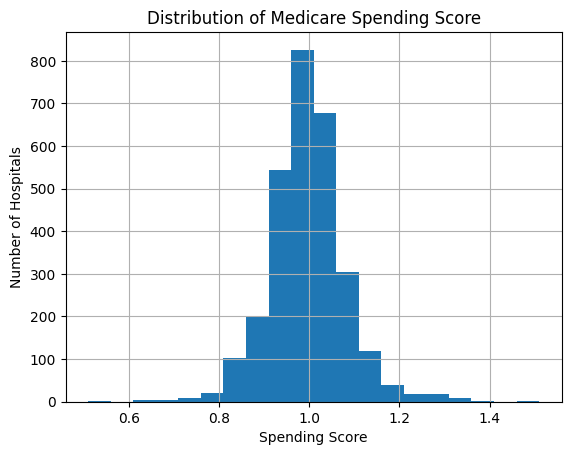

In [30]:
medicare_data['spending_score'].hist(bins=20)
plt.title("Distribution of Medicare Spending Score")
plt.xlabel("Spending Score")
plt.ylabel("Number of Hospitals")
plt.show()

##### Above histogram shows the distribution of Medicare spending Scores across hospitals. Most hospitals have spending score close tho 1.0 which means the national average. this suggests the majority of hospitals spend a similar amount of national average on patients. only a small number of hospitals spending significiantly less or more than nationals Average.

In [31]:
# Loading unplanned hospital visits
unplanned_visit_data= pd.read_csv("../data/Unplanned_Hospital_visits-Hospital.csv")
unplanned_visit_data.head(5)

# The unplanned visit dataset contains the information about hospital visits or return visits for different medical conditions.

C:\Users\archa\AppData\Local\Temp\ipykernel_29068\3807474166.py:2: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  unplanned_visit_data= pd.read_csv("../data/Unplanned_Hospital_visits-Hospital.csv")


,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Measure ID,Measure Name,Compared to National,Denominator,Score,Lower Estimate,Higher Estimate,Number of Patients,Number of Patients Returned,Footnote,Start Date,End Date
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,EDAC_30_AMI,Hospital return days for heart attack patients,Fewer Days Than Average per 100 Discharges,273,-15.6,-25.9,-4.2,264,68,NaN,7/1/2021,6/30/2024
1,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,EDAC_30_HF,Hospital return days for heart failure patients,Average Days per 100 Discharges,652,-1.1,-10,7.9,541,186,NaN,7/1/2021,6/30/2024
2,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,EDAC_30_PN,Hospital return days for pneumonia patients,More Days Than Average per 100 Discharges,507,17.4,8.2,27.5,471,114,NaN,7/1/2021,6/30/2024
3,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Hybrid_HWR,Hybrid Hospital-Wide All-Cause Readmission Mea...,No Different Than the National Rate,2824,15.1,13.2,17.2,Not Applicable,Not Applicable,NaN,7/1/2023,6/30/2024
4,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,OP_32,Rate of unplanned hospital visits after colono...,No Different Than the National Rate,218,12.8,9.4,17.4,Not Applicable,Not Applicable,NaN,1/1/2021,12/31/2023


In [32]:
unplanned_visit_data.dtypes

Facility ID                    object
Facility Name                  object
Address                        object
City/Town                      object
State                          object
ZIP Code                        int64
County/Parish                  object
Telephone Number               object
Measure ID                     object
Measure Name                   object
Compared to National           object
Denominator                    object
Score                          object
Lower Estimate                 object
Higher Estimate                object
Number of Patients             object
Number of Patients Returned    object
Footnote                       object
Start Date                     object
End Date                       object
dtype: object

In [33]:
# Unplanned  visit rows and columns
unplanned_visit_data.shape

(67074, 20)

In [34]:
# checking for null values
unplanned_visit_data.isnull().sum()

Facility ID                        0
Facility Name                      0
Address                            0
City/Town                          0
State                              0
ZIP Code                           0
County/Parish                      0
Telephone Number                   0
Measure ID                         0
Measure Name                       0
Compared to National               0
Denominator                        0
Score                              0
Lower Estimate                     0
Higher Estimate                    0
Number of Patients                 0
Number of Patients Returned        0
Footnote                       34758
Start Date                         0
End Date                           0
dtype: int64

In [35]:
#columns in unplanned visit data
unplanned_visit_data.columns

Index(['Facility ID', 'Facility Name', 'Address', 'City/Town', 'State',
       'ZIP Code', 'County/Parish', 'Telephone Number', 'Measure ID',
       'Measure Name', 'Compared to National', 'Denominator', 'Score',
       'Lower Estimate', 'Higher Estimate', 'Number of Patients',
       'Number of Patients Returned', 'Footnote', 'Start Date', 'End Date'],
      dtype='object')

In [36]:
# removing unnecessery columns from unplanned visit data
unplanned_visit_data = unplanned_visit_data.drop(columns=['Address', 'City/Town',
       'ZIP Code', 'County/Parish', 'Telephone Number', 'Measure ID',
         'Denominator', 'Facility Name',	'State',
       'Lower Estimate', 'Higher Estimate', 
        'Footnote'])
unplanned_visit_data.head(5)

,Facility ID,Measure Name,Compared to National,Score,Number of Patients,Number of Patients Returned,Start Date,End Date
0,010001,Hospital return days for heart attack patients,Fewer Days Than Average per 100 Discharges,-15.6,264,68,7/1/2021,6/30/2024
1,010001,Hospital return days for heart failure patients,Average Days per 100 Discharges,-1.1,541,186,7/1/2021,6/30/2024
2,010001,Hospital return days for pneumonia patients,More Days Than Average per 100 Discharges,17.4,471,114,7/1/2021,6/30/2024
3,010001,Hybrid Hospital-Wide All-Cause Readmission Mea...,No Different Than the National Rate,15.1,Not Applicable,Not Applicable,7/1/2023,6/30/2024
4,010001,Rate of unplanned hospital visits after colono...,No Different Than the National Rate,12.8,Not Applicable,Not Applicable,1/1/2021,12/31/2023


In [37]:
# some rows in Number of Patients and Number of Patients Returned_returned columns have 'Not Applicable. I'm replacing this to NaN, this allows numeric analysis.
unplanned_visit_data['Number of Patients'] = unplanned_visit_data['Number of Patients'].replace('Not Applicable', np.nan)
unplanned_visit_data['Number of Patients Returned']= unplanned_visit_data['Number of Patients Returned'].replace('Not Applicable', np.nan)

# some rows in Score, number of patients and number of patients columns have 'Not Available'. replacing this to NaN.
unplanned_visit_data[['Score', 'Number of Patients', 'Number of Patients Returned']] = unplanned_visit_data[['Score', 'Number of Patients', 'Number of Patients Returned']].replace('Not Available', np.nan)

In [38]:
# renaming columns cleanly
unplanned_visit_data = rename_columns(unplanned_visit_data, {
    'Facility ID' : 'facility_id',
    'Measure Name' : 'measure_name',
    'Compared to National' : 'compared_to_national',
    'Score' : 'visit_score',
    'Number of Patients': 'num_patients',
    'Number of Patients Returned': 'num_patient_returned',
    'Start Date': 'start_date',
    'End Date' : 'end_date'
})
unplanned_visit_data.head(5)


,facility_id,measure_name,compared_to_national,visit_score,num_patients,num_patient_returned,start_date,end_date
0,010001,Hospital return days for heart attack patients,Fewer Days Than Average per 100 Discharges,-15.6,264,68,7/1/2021,6/30/2024
1,010001,Hospital return days for heart failure patients,Average Days per 100 Discharges,-1.1,541,186,7/1/2021,6/30/2024
2,010001,Hospital return days for pneumonia patients,More Days Than Average per 100 Discharges,17.4,471,114,7/1/2021,6/30/2024
3,010001,Hybrid Hospital-Wide All-Cause Readmission Mea...,No Different Than the National Rate,15.1,NaN,NaN,7/1/2023,6/30/2024
4,010001,Rate of unplanned hospital visits after colono...,No Different Than the National Rate,12.8,NaN,NaN,1/1/2021,12/31/2023


In [39]:
# checking duplicate rows
unplanned_visit_data.duplicated().sum()

np.int64(0)

In [40]:
unplanned_visit_data.dtypes

facility_id             object
measure_name            object
compared_to_national    object
visit_score             object
num_patients            object
num_patient_returned    object
start_date              object
end_date                object
dtype: object

In [41]:
#converting start_date and end_date to datetime calling function

unplanned_visit_data= convert_to_datetime(unplanned_visit_data,['start_date', 'end_date'])

#converting visit_score, num_patients, and num_patients returns from string to numeric data type calling function
unplanned_visit_data = convert_to_numeric(unplanned_visit_data,['visit_score','num_patients','num_patient_returned'])

In [42]:
# Summary statics for unplanned visit data
unplanned_visit_data.describe()

,visit_score,num_patients,num_patient_returned,start_date,end_date
count,35358.000000,8352.000000,8352.000000,67074,67074
mean,11.147412,225.679478,65.376437,2021-12-04 20:34:17.142857216,2024-05-09 00:00:00
min,-90.700000,17.000000,1.000000,2021-01-01 00:00:00,2023-12-31 00:00:00
25%,5.200000,69.000000,20.000000,2021-07-01 00:00:00,2023-12-31 00:00:00
50%,13.800000,151.000000,43.000000,2021-07-01 00:00:00,2024-06-30 00:00:00
75%,17.000000,305.000000,88.000000,2023-01-01 00:00:00,2024-06-30 00:00:00
max,247.400000,3216.000000,959.000000,2023-07-01 00:00:00,2024-06-30 00:00:00
std,15.735873,230.499300,67.767445,NaN,NaN


In [43]:
# types of measures
unplanned_visit_data['measure_name'].unique()

array(['Hospital return days for heart attack patients',
       'Hospital return days for heart failure patients',
       'Hospital return days for pneumonia patients',
       'Hybrid Hospital-Wide All-Cause Readmission Measure (HWR)',
       'Rate of unplanned hospital visits after colonoscopy (per 1,000 colonoscopies)',
       'Rate of inpatient admissions for patients receiving outpatient chemotherapy',
       'Rate of emergency department (ED) visits for patients receiving outpatient chemotherapy',
       'Ratio of unplanned hospital visits after hospital outpatient surgery',
       'Acute Myocardial Infarction (AMI) 30-Day Readmission Rate',
       'Rate of readmission for CABG',
       'Rate of readmission for chronic obstructive pulmonary disease (COPD) patients',
       'Heart failure (HF) 30-Day Readmission Rate',
       'Rate of readmission after hip/knee replacement',
       'Pneumonia (PN) 30-Day Readmission Rate'], dtype=object)

In [44]:
unplanned_visit_data.groupby('measure_name')['visit_score'].mean().sort_values(ascending=False).round(2)

measure_name
Heart failure (HF) 30-Day Readmission Rate                                                 19.71
Rate of readmission for chronic obstructive pulmonary disease (COPD) patients              18.23
Pneumonia (PN) 30-Day Readmission Rate                                                     15.99
Hybrid Hospital-Wide All-Cause Readmission Measure (HWR)                                   14.98
Acute Myocardial Infarction (AMI) 30-Day Readmission Rate                                  13.63
Rate of unplanned hospital visits after colonoscopy (per 1,000 colonoscopies)              13.07
Rate of inpatient admissions for patients receiving outpatient chemotherapy                10.78
Rate of readmission for CABG                                                               10.64
Hospital return days for heart attack patients                                              7.14
Hospital return days for pneumonia patients                                                 6.22
Rate of emergency

In [45]:
unplanned_visit_data['measure_name'].unique()



array(['Hospital return days for heart attack patients',
       'Hospital return days for heart failure patients',
       'Hospital return days for pneumonia patients',
       'Hybrid Hospital-Wide All-Cause Readmission Measure (HWR)',
       'Rate of unplanned hospital visits after colonoscopy (per 1,000 colonoscopies)',
       'Rate of inpatient admissions for patients receiving outpatient chemotherapy',
       'Rate of emergency department (ED) visits for patients receiving outpatient chemotherapy',
       'Ratio of unplanned hospital visits after hospital outpatient surgery',
       'Acute Myocardial Infarction (AMI) 30-Day Readmission Rate',
       'Rate of readmission for CABG',
       'Rate of readmission for chronic obstructive pulmonary disease (COPD) patients',
       'Heart failure (HF) 30-Day Readmission Rate',
       'Rate of readmission after hip/knee replacement',
       'Pneumonia (PN) 30-Day Readmission Rate'], dtype=object)

In [46]:
unplanned_visit_data.groupby('measure_name')['visit_score'].mean().sort_values().round(2)

measure_name
Ratio of unplanned hospital visits after hospital outpatient surgery                        1.03
Rate of readmission after hip/knee replacement                                              4.86
Hospital return days for heart failure patients                                             5.16
Rate of emergency department (ED) visits for patients receiving outpatient chemotherapy     5.54
Hospital return days for pneumonia patients                                                 6.22
Hospital return days for heart attack patients                                              7.14
Rate of readmission for CABG                                                               10.64
Rate of inpatient admissions for patients receiving outpatient chemotherapy                10.78
Rate of unplanned hospital visits after colonoscopy (per 1,000 colonoscopies)              13.07
Acute Myocardial Infarction (AMI) 30-Day Readmission Rate                                  13.63
Hybrid Hospital-W

#### Connect to SQLite Database
##### In this step I'm creating a connection to SQLite database. where all the cleaned datasets will be stored.

In [53]:
# Creating connection
connection = sqlite3.connect("../data/hospital_performance.db")
cursor = connection.cursor()

# Loading Cleaned datasets into SQL database as seperate tables.
hospital_info.to_sql('hospital_info', connection, if_exists='replace', index=False)
medicare_data.to_sql('medicare_spending', connection, if_exists='replace', index=False)
unplanned_visit_data.to_sql('unplanned_visits', connection, if_exists='replace', index=False)


67074

In [73]:
# varifying the tables to confirm the database is successfully created.
pd.read_sql("SELECT * FROM hospital_info", connection)
pd.read_sql("SELECT * FROM medicare_spending", connection)
pd.read_sql("SELECT * FROM unplanned_visits ", connection)



,facility_id,measure_name,compared_to_national,visit_score,num_patients,num_patient_returned,start_date,end_date
0,010001,Hospital return days for heart attack patients,Fewer Days Than Average per 100 Discharges,-15.6,264.0,68.0,2021-07-01 00:00:00,2024-06-30 00:00:00
1,010001,Hospital return days for heart failure patients,Average Days per 100 Discharges,-1.1,541.0,186.0,2021-07-01 00:00:00,2024-06-30 00:00:00
2,010001,Hospital return days for pneumonia patients,More Days Than Average per 100 Discharges,17.4,471.0,114.0,2021-07-01 00:00:00,2024-06-30 00:00:00
3,010001,Hybrid Hospital-Wide All-Cause Readmission Mea...,No Different Than the National Rate,15.1,NaN,NaN,2023-07-01 00:00:00,2024-06-30 00:00:00
4,010001,Rate of unplanned hospital visits after colono...,No Different Than the National Rate,12.8,NaN,NaN,2021-01-01 00:00:00,2023-12-31 00:00:00
...,...,...,...,...,...,...,...,...
67069,671301,Rate of readmission for CABG,Not Available,NaN,NaN,NaN,2021-07-01 00:00:00,2024-06-30 00:00:00
67070,671301,Rate of readmission for chronic obstructive pu...,Not Available,NaN,NaN,NaN,2021-07-01 00:00:00,2024-06-30 00:00:00
67071,671301,Heart failure (HF) 30-Day Readmission Rate,Not Available,NaN,NaN,NaN,2021-07-01 00:00:00,2024-06-30 00:00:00
67072,671301,Rate of readmission after hip/knee replacement,Not Available,NaN,NaN,NaN,2021-07-01 00:00:00,2024-06-30 00:00:00


### Build Relational Tables